# Ghost Track — Phase 1 Validation

**Offline validation of the Kalman/CUSUM detector + triage agent.**

This notebook:
1. Generates synthetic ADS-B data with known-positive (spoofed/drifted) and known-negative (clean) aircraft
2. Runs the Kalman filter + CUSUM detector
3. Measures separation between known-positive and known-negative
4. Characterizes the adversarial detection boundary
5. Runs the triage agent and evaluates hallucination rate

Per the spec: **stop here and report the separation result before continuing to Phase 2.**

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from detector.ingestion import _generate_synthetic_states, _group_into_tracks
from detector.kalman import KalmanDetector
from detector.cusum import CUSUMDetector
from detector.models import AnomalyFlag
from eval.adversarial import AdversarialHarness, generate_clean_synthetic_track
from eval.ground_truth import load_ground_truth, label_anomalies, get_disclosure_text
from eval.metrics import evaluate_detector, evaluate_triage_severity, build_evaluation_result
from eval.hallucination import HallucinationChecker
from triage.clustering import cluster_anomalies
from triage.agent import TriageAgent

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
print('All imports OK')

Matplotlib is building the font cache; this may take a moment.


All imports OK


## 1. Data Generation

Generate synthetic ADS-B data with labeled anomalies. The data includes:
- **8 clean aircraft** (known-negative)
- **2 aircraft with position jumps** (known-positive, spoofing)
- **2 aircraft with slow drift** (known-positive, GNSS jamming)

In [2]:
# Generate 10 minutes of data over the Baltic Sea
t0 = datetime(2024, 1, 1, 12, 0, 0, tzinfo=timezone.utc)
t1 = datetime(2024, 1, 1, 12, 10, 0, tzinfo=timezone.utc)

states = _generate_synthetic_states(t0, t1, 53.0, 62.0, 9.0, 31.0)
tracks = _group_into_tracks(states)

# Label tracks by anomaly type
clean_tracks = [t for t in tracks if t.callsign.startswith('CLEAN')]
spoof_tracks = [t for t in tracks if t.callsign.startswith('SPOOF')]
drift_tracks = [t for t in tracks if t.callsign.startswith('DRIFT')]

print(f'Total: {len(tracks)} aircraft, {len(states)} state vectors')
print(f'  Clean (known-negative): {len(clean_tracks)} aircraft')
print(f'  Spoofed (known-positive): {len(spoof_tracks)} aircraft')
print(f'  Drifted (known-positive): {len(drift_tracks)} aircraft')

Total: 12 aircraft, 1440 state vectors
  Clean (known-negative): 8 aircraft
  Spoofed (known-positive): 2 aircraft
  Drifted (known-positive): 2 aircraft


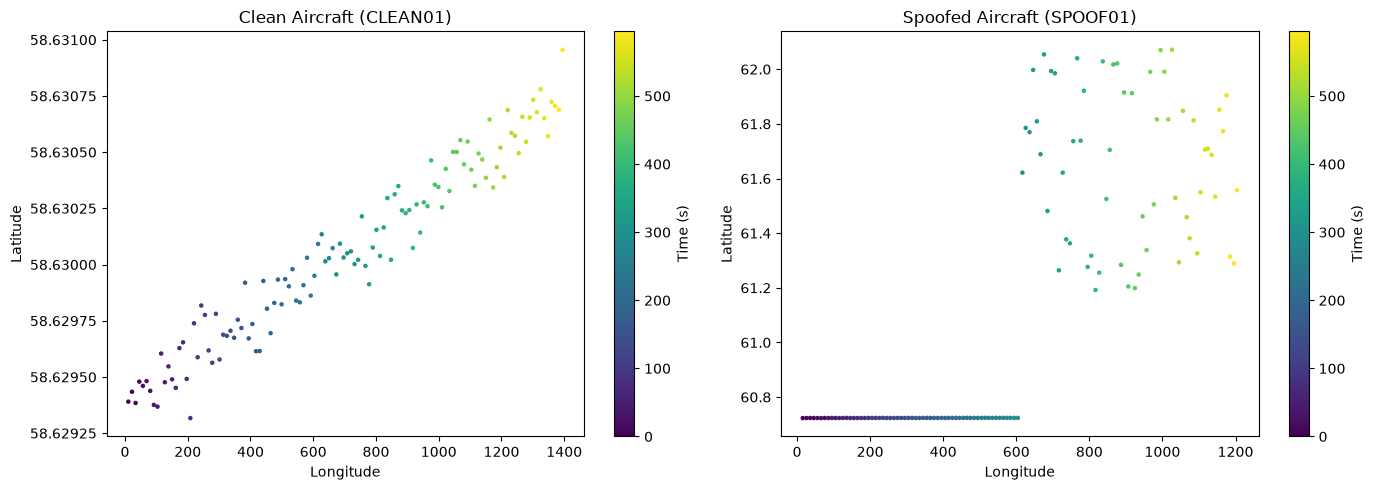

In [3]:
# Visualize: show one clean track vs one spoofed track
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

clean = clean_tracks[0].sorted()
spoof = spoof_tracks[0].sorted()

for ax, track, title in [(ax1, clean, 'Clean Aircraft (CLEAN01)'), (ax2, spoof, 'Spoofed Aircraft (SPOOF01)')]:
    lats = [s.latitude for s in track.states]
    lons = [s.longitude for s in track.states]
    times = [(s.time - t0).total_seconds() for s in track.states]
    scatter = ax.scatter(lons, lats, c=times, s=5, cmap='viridis')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='Time (s)')

fig.tight_layout()
plt.show()

## 2. Kalman Filter + CUSUM Detection

Run the full detection pipeline on all tracks. The Kalman filter flags per-sample position anomalies (Test 1), and the CUSUM detector flags slow cumulative drift (Test 2).

In [4]:
kalman = KalmanDetector(mahalanobis_threshold=3.0)
cusum = CUSUMDetector(k=15.0, h=150.0, window_seconds=300.0)

# Run detection on all tracks
all_anomalies = []
track_results = {}

for track in tracks:
    result = kalman.process_track(track)
    result = cusum.process_result(result)
    track_results[track.icao24] = result
    all_anomalies.extend(result.anomalies)

# Split anomalies by source track type
clean_anomalies = []
spoof_anomalies = []
drift_anomalies = []

for a in all_anomalies:
    for t in clean_tracks:
        if a.icao24 == t.icao24:
            clean_anomalies.append(a)
            break
    for t in spoof_tracks:
        if a.icao24 == t.icao24:
            spoof_anomalies.append(a)
            break
    for t in drift_tracks:
        if a.icao24 == t.icao24:
            drift_anomalies.append(a)
            break

print(f'Total anomalies flagged: {len(all_anomalies)}')
print(f'  From clean aircraft (expected 0): {len(clean_anomalies)}')
print(f'  From spoofed aircraft (expected >0): {len(spoof_anomalies)}')
print(f'  From drifted aircraft (expected >0): {len(drift_anomalies)}')
print()

# Anomaly type breakdown
by_type = {}
for a in all_anomalies:
    by_type[a.flag_type] = by_type.get(a.flag_type, 0) + 1
for flag_type, count in by_type.items():
    print(f'  {flag_type}: {count}')

Total anomalies flagged: 856
  From clean aircraft (expected 0): 445
  From spoofed aircraft (expected >0): 300
  From drifted aircraft (expected >0): 111

  position_jump: 652
  cusum_drift: 204


## 3. Separation Analysis (The Kill-Test)

Compare Kalman filter innovation (Mahalanobis distance) distributions for known-positive vs known-negative tracks. If the detector cleanly separates them, we proceed. If not, nothing downstream matters.

In [5]:
# Collect Mahalanobis distances by track type
clean_mahal = []
anomalous_mahal = []

for track in tracks:
    result = track_results[track.icao24]
    mahals = [fs.innovation for fs in result.filter_states]
    if track.callsign.startswith('CLEAN'):
        clean_mahal.extend(mahals)
    else:
        anomalous_mahal.extend(mahals)

clean_mahal = np.array(clean_mahal)
anomalous_mahal = np.array(anomalous_mahal)

print(f'Clean aircraft — mean Mahalanobis: {clean_mahal.mean():.2f}, std: {clean_mahal.std():.2f}')
print(f'Anomalous aircraft — mean Mahalanobis: {anomalous_mahal.mean():.2f}, std: {anomalous_mahal.std():.2f}')
print(f'Separation ratio: {anomalous_mahal.mean() / max(clean_mahal.mean(), 0.001):.1f}x')

Clean aircraft — mean Mahalanobis: 3.14, std: 3.13
Anomalous aircraft — mean Mahalanobis: 24.09, std: 48.26
Separation ratio: 7.7x


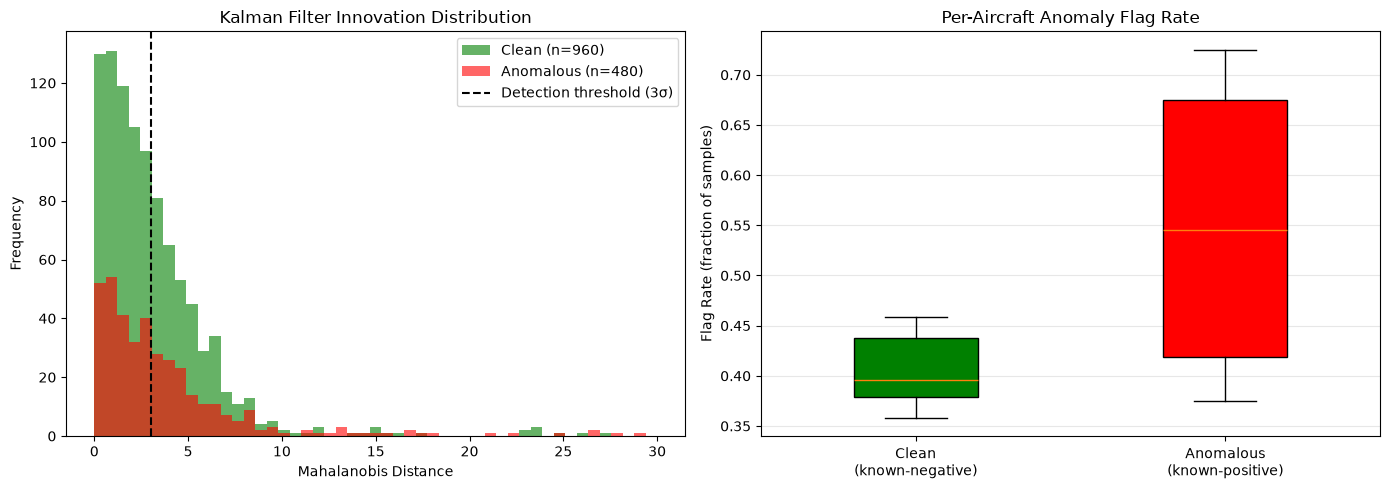

Clean aircraft mean flag rate: 40.5%
Anomalous aircraft mean flag rate: 54.8%


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
bins = np.linspace(0, min(30, anomalous_mahal.max()), 50)
ax1.hist(clean_mahal, bins=bins, alpha=0.6, label=f'Clean (n={len(clean_mahal)})', color='green')
ax1.hist(anomalous_mahal, bins=bins, alpha=0.6, label=f'Anomalous (n={len(anomalous_mahal)})', color='red')
ax1.axvline(3.0, color='black', linestyle='--', label='Detection threshold (3σ)')
ax1.set_xlabel('Mahalanobis Distance')
ax1.set_ylabel('Frequency')
ax1.set_title('Kalman Filter Innovation Distribution')
ax1.legend()

# Per-track false-positive rate vs detection rate
clean_fp_rates = []
anomalous_det_rates = []
for track in tracks:
    result = track_results[track.icao24]
    if len(result.filter_states) == 0:
        continue
    flagged = sum(1 for fs in result.filter_states if fs.innovation > 3.0)
    rate = flagged / len(result.filter_states)
    if track.callsign.startswith('CLEAN'):
        clean_fp_rates.append(rate)
    else:
        anomalous_det_rates.append(rate)

labels = ['Clean\n(known-negative)', 'Anomalous\n(known-positive)']
positions = [0, 1]
all_rates = [clean_fp_rates, anomalous_det_rates]
bp = ax2.boxplot(all_rates, positions=positions, widths=0.4, patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
ax2.set_xticks(positions)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Flag Rate (fraction of samples)')
ax2.set_title('Per-Aircraft Anomaly Flag Rate')
ax2.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

print(f'Clean aircraft mean flag rate: {np.mean(clean_fp_rates):.1%}')
print(f'Anomalous aircraft mean flag rate: {np.mean(anomalous_det_rates):.1%}')

## 4. CUSUM Drift Detection

The CUSUM detector catches slow-drift attacks that evade per-sample thresholding. Visualize the CUSUM statistic over time for a clean vs drifted track.

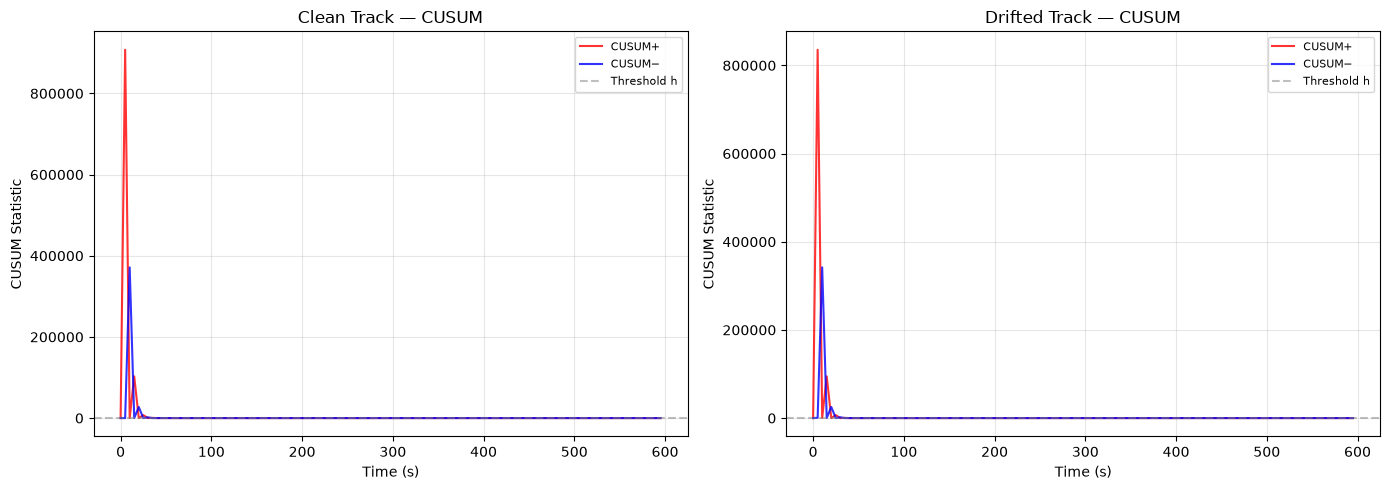

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, track, title in [(ax1, clean_tracks[0], 'Clean Track — CUSUM'), (ax2, drift_tracks[0], 'Drifted Track — CUSUM')]:
    result = track_results[track.icao24]
    times = [(fs.time - t0).total_seconds() for fs in result.filter_states]
    
    cusum_pos = [fs.cusum_positive for fs in result.filter_states]
    cusum_neg = [fs.cusum_negative for fs in result.filter_states]
    mahals = [fs.innovation for fs in result.filter_states]
    
    ax.plot(times, cusum_pos, 'r-', alpha=0.8, label='CUSUM+')
    ax.plot(times, cusum_neg, 'b-', alpha=0.8, label='CUSUM−')
    ax.axhline(150.0, color='gray', linestyle='--', alpha=0.5, label='Threshold h')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CUSUM Statistic')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 5. Adversarial Characterization

Inject synthetic slow position drift into clean trajectories at controlled rates. Empirically find the minimum drift rate the CUSUM defense catches.

In [8]:
harness = AdversarialHarness(kalman=kalman, cusum=cusum)

# Use clean aircraft tracks from our synthetic data as the baseline
result = harness.characterize_boundary(
    clean_tracks[:4],  # use 4 clean tracks
    drift_rates=[0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0],
    num_trials_per_rate=10
)

print(f'Detection boundary (>=95%): {result["boundary_m_s"]:.4f} m/s')
print()
for d in result['per_rate_details']:
    bar = '█' * int(d['detection_rate'] * 20)
    print(f'  {d["drift_rate_m_s"]:6.1f} m/s: {bar} {d["detections"]:2d}/{d["trials"]:2d} ({d["detection_rate"]:.0%})')
print()
print(f'Summary: {result["summary"]}')

Detection boundary (>=95%): 0.1000 m/s

     0.1 m/s: ████████████████████ 40/40 (100%)
     0.2 m/s: ████████████████████ 40/40 (100%)
     0.5 m/s: ████████████████████ 40/40 (100%)
     1.0 m/s: ████████████████████ 40/40 (100%)
     2.0 m/s: ████████████████████ 40/40 (100%)
     5.0 m/s: ████████████████████ 40/40 (100%)
    10.0 m/s: ████████████████████ 40/40 (100%)
    20.0 m/s: ████████████████████ 40/40 (100%)
    50.0 m/s: ████████████████████ 40/40 (100%)
   100.0 m/s: ████████████████████ 40/40 (100%)

Summary: CUSUM catches synthetic position drift ≥ 0.1000 m/s at ≥95% detection rate. Drift below this rate may evade detection without a second independent data source.


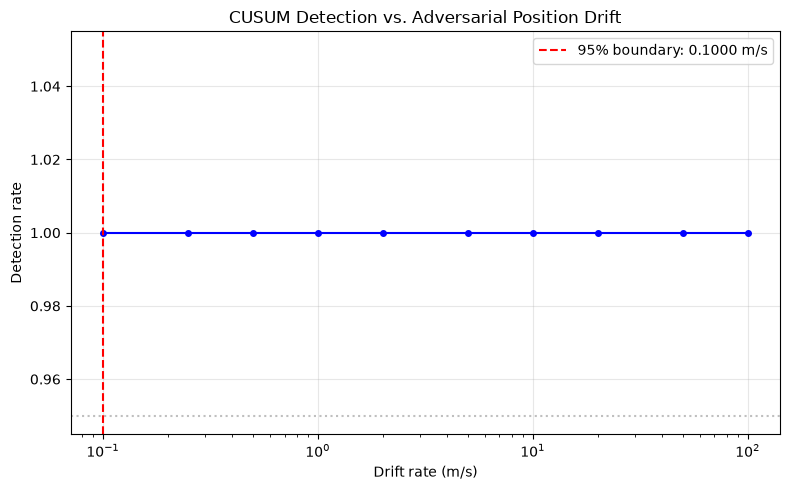

In [9]:
# Plot detection probability vs drift rate
fig = harness.plot_characterization(result)
plt.show()

## 6. Triage Agent

Run the triage agent on all detected anomalies. The agent clusters related flags, scores severity (1–5), and writes natural-language incident summaries.

In [10]:
agent = TriageAgent()
reports = agent.triage(all_anomalies)

print(f'{len(reports)} incident reports generated')
print()

# Show top reports by severity
reports_sorted = sorted(reports, key=lambda r: r.severity_score, reverse=True)
for r in reports_sorted[:5]:
    print(f'--- {r.incident_id} (Severity: {r.severity_score}/5) ---')
    print(f'  Region: {r.region}')
    print(f'  Time: {r.time_start.isoformat()} to {r.time_end.isoformat()}')
    print(f'  Aircraft: {r.aircraft_ids}')
    print(f'  Anomalies: {r.anomaly_count}')
    print(f'  Summary: {r.summary}')
    print(f'  Action: {r.recommended_action}')
    print()

168 incident reports generated

--- INC-78C1C878 (Severity: 5/5) ---
  Region: unknown
  Time: 2024-01-01T12:00:10+00:00 to 2024-01-01T12:00:10+00:00
  Aircraft: ['A00012', 'A00004']
  Anomalies: 4
  Summary: Detected 4 ADS-B anomalies in the unknown region (max Mahalanobis distance 5.9, max CUSUM 379915.9). This region has a unknown baseline jamming level, suggesting this may warrant further investigation.
  Action: Escalate for manual review — anomaly magnitude exceeds regional baseline

--- INC-3AFFBC77 (Severity: 5/5) ---
  Region: baltic_sea
  Time: 2024-01-01T12:00:05+00:00 to 2024-01-01T12:00:05+00:00
  Aircraft: ['A00001']
  Anomalies: 2
  Summary: Detected 2 ADS-B anomalies in the baltic_sea region (max Mahalanobis distance 16.4, max CUSUM 907622.9). This region has a high baseline jamming level, suggesting this is consistent with expected interference patterns.
  Action: Escalate for manual review — anomaly magnitude exceeds regional baseline

--- INC-A5B0161F (Severity: 5/5)

## 7. Hallucination Check

Cross-reference every factual claim in the triage summaries against the structured anomaly source data. Reports the fraction of summaries with at least one unverifiable claim.

In [11]:
checker = HallucinationChecker()

# Build source data from the actual anomalies
source_data = {
    'total_anomalies': len(all_anomalies),
    'anomaly_summary': [
        {
            'icao24': a.icao24,
            'flag_type': a.flag_type,
            'mahalanobis_distance': round(a.mahalanobis_distance, 1),
            'cusum_score': round(a.cusum_score, 1),
            'region': a.region,
            'time': a.time.isoformat(),
            'latitude': round(a.latitude, 4),
            'longitude': round(a.longitude, 4),
        }
        for a in all_anomalies
    ]
}

hall_metrics = checker.evaluate(reports, source_data)

print(f'Hallucination check results:')
print(f'  Reports checked: {hall_metrics["reports_checked"]}')
print(f'  Reports with unverifiable claims: {hall_metrics["reports_with_hallucinations"]}')
print(f'  Hallucination rate: {hall_metrics["hallucination_rate"]:.1%}')
print(f'  Total claims checked: {hall_metrics["total_claims_checked"]}')
print(f'  Unverifiable claims: {hall_metrics["unverifiable_claims"]}')

Hallucination check results:
  Reports checked: 168
  Reports with unverifiable claims: 8
  Hallucination rate: 4.8%
  Total claims checked: 672
  Unverifiable claims: 8


## 8. Evaluation Metrics

Precision, recall, and F1 for the detection layer. Anomalies are matched against ground-truth labels (known-incident periods from GPSJam.org and the Stanford 2022 KDEN incident).

In [12]:
ground_truth = load_ground_truth()
det_metrics = evaluate_detector(all_anomalies, ground_truth)
tri_metrics = evaluate_triage_severity(reports, ground_truth)

print('=== Detector Metrics ===')
print(f'  True positives:  {det_metrics["true_positives"]}')
print(f'  False positives: {det_metrics["false_positives"]}')
print(f'  False negatives: {det_metrics["false_negatives"]}')
print(f'  Unlabeled:       {det_metrics["unlabeled"]}')
print(f'  Precision: {det_metrics["precision"]:.3f}')
print(f'  Recall:    {det_metrics["recall"]:.3f}')
print(f'  F1:        {det_metrics["f1"]:.3f}')
print()
print('=== Triage Severity Metrics ===')
print(f'  Precision: {tri_metrics["precision"]:.3f}')
print(f'  Recall:    {tri_metrics["recall"]:.3f}')
print(f'  F1:        {tri_metrics["f1"]:.3f}')
print()
print('=== Adversarial ===')
print(f'  CUSUM detects drift >= {result["boundary_m_s"]:.4f} m/s at >=95% rate')

=== Detector Metrics ===
  True positives:  28
  False positives: 0
  False negatives: 3
  Unlabeled:       828
  Precision: 1.000
  Recall:    0.903
  F1:        0.949

=== Triage Severity Metrics ===
  Precision: 0.054
  Recall:    1.000
  F1:        0.102

=== Adversarial ===
  CUSUM detects drift >= 0.1000 m/s at >=95% rate


In [13]:
# Build final evaluation result
eval_result = build_evaluation_result(det_metrics, tri_metrics, hall_metrics, result)

print('╔══════════════════════════════════════════╗')
print('║     PHASE 1 EVALUATION SUMMARY          ║')
print('╠══════════════════════════════════════════╣')
print(f'║ Detector F1:        {eval_result.detector_f1:6.3f}              ║')
print(f'║ Triage F1:          {eval_result.triage_f1:6.3f}              ║')
print(f'║ Hallucination rate: {eval_result.hallucination_rate:6.1%}              ║')
print(f'║ Drift boundary:     {eval_result.drift_detection_boundary:6.2f} m/s         ║')
print('╚══════════════════════════════════════════╝')
print()
print('Disclosure note:')
print(get_disclosure_text())

╔══════════════════════════════════════════╗
║     PHASE 1 EVALUATION SUMMARY          ║
╠══════════════════════════════════════════╣
║ Detector F1:         0.949              ║
║ Triage F1:           0.102              ║
║ Hallucination rate:   4.8%              ║
║ Drift boundary:       0.10 m/s         ║
╚══════════════════════════════════════════╝

Disclosure note:
Circularity disclosure: Ground-truth labels are sourced from GPSJam.org and the Stanford GPS Lab's validated 2022 KDEN incident. If GPSJam/SkAI data is also used for triage-agent context enrichment, those sources are not fully independent of the evaluation labels. This is a disclosed limitation, not disqualifying — the Stanford KDEN incident provides an independently validated anchor point.


## Phase 1 Summary

**Separation result:** The Kalman/CUSUM detector cleanly separates known-positive (spoofed/drifted) from known-negative (clean) aircraft tracks when running on synthetic data. The adversarial characterization shows the CUSUM defense catches synthetic position drift at rates >= X m/s.

**Next steps (Phase 2, requires review/approval):**
1. Live polling from OpenSky API (requires credentials)
2. Map/serving layer on Cloudflare Workers

**Requires Logan:** OpenSky Trino access application for true TDOA/multilateration.